# DSCI 641 - Assignment 2 - Manyu Ghildiyal

## Preparing Data

### Import Statements

In [1]:
import pandas as pd
import numpy as np
import lenskit
import lift
import logging
import glob

from lenskit.data import load_movielens, Dataset
from lenskit import topn_pipeline, Pipeline
from lenskit.splitting import split_temporal_fraction
from lenskit.basic import BiasScorer, PopScorer
from lenskit import batch, predict
from lenskit.metrics import RBP, NDCG, MeasurementCollector, RMSE
from lenskit.knn import UserKNNScorer, ItemKNNScorer, SLIMScorer
from lenskit.als import BiasedMFScorer, ImplicitMFScorer
from lenskit.logging import LoggingConfig
from lenskit.data import ItemListCollection

import matplotlib.pyplot as plt

### Loading & Parsing Data

In [2]:
#Loading Dataset using load_movielens
movie_dataset = load_movielens('ml-20m.zip')

In [3]:
#global temporal split
split = split_temporal_fraction(movie_dataset, 0.15, filter_test_users=True)

In [4]:
#Test Item List Collection
test = split.test
#Did the same for train just to be safe
train = split.train

## Evaluating Recommendation Models


In [6]:
#Logger Setup
LoggingConfig().apply()
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)  


#pipeline - The pipeline
#parquet_name - Name of the parquet file we are making
#predict - Boolean, tells method whether to do predict or not. Defaults to False
def customMethod(pipeline, parquet_name:str, predict:bool =False):
    logger.info(f"Starting recommendations for {parquet_name}")
    recs = batch.recommend(pipeline, test, n=20)
    recs.save_parquet(f'{parquet_name}_recs.parquet')
    logger.info(f"Saved recommendations → {parquet_name}_recs.parquet")
    if predict:
        logger.info(f"Starting predictions for {parquet_name}")
        pred = batch.predict(pipeline, test)
        pred.save_parquet(f'{parquet_name}_pred.parquet')
        logger.info(f"Saved predictions → {parquet_name}_pred.parquet")
    logger.info(f"Finished {parquet_name}")

### Popular

In [7]:
pop_pipe = topn_pipeline(PopScorer())
pop_pipe.train(train)
customMethod(pop_pipe,'pop')

2026-04-29T16:34:29 [info     ] training pipeline components   [lenskit.pipeline] pipeline=None
2026-04-29T16:34:29 [info     ] counting item popularity       [lenskit.basic.popularity]
2026-04-29T16:34:32 [info     ] computing quantiles for 27278 items [lenskit.basic.popularity]
2026-04-29T16:34:32 [info     ] Starting recommendations for pop [__main__]
2026-04-29T16:34:32 [info     ] beginning batch run            [lenskit.batch] n_jobs=1 n_queries=5594 name=None
2026-04-29T16:34:39 [info     ] finished running in 7.79s      [lenskit.batch] n_jobs=1 n_queries=5594 name=None time_per_query=1.4ms
2026-04-29T16:34:40 [info     ] Saved recommendations → pop_recs.parquet [__main__]
2026-04-29T16:34:40 [info     ] Finished pop                   [__main__]


### Bias

In [8]:
bias_pipe = topn_pipeline(BiasScorer(), n=20, predicts_ratings=True)
bias_pipe.train(train)
customMethod(bias_pipe,'bias',True)

2026-04-29T16:34:40 [info     ] training pipeline components   [lenskit.pipeline] pipeline=None
2026-04-29T16:34:40 [info     ] building bias model for 17000223 ratings [lenskit.basic.bias]
2026-04-29T16:34:40 [info     ] global mean: 3.514             [lenskit.basic.bias]
2026-04-29T16:34:43 [info     ] computed biases for 27278 items [lenskit.basic.bias]
2026-04-29T16:34:45 [info     ] computed biases for 138493 users [lenskit.basic.bias]
2026-04-29T16:34:45 [info     ] building bias model for 17000223 ratings [lenskit.basic.bias]
2026-04-29T16:34:46 [info     ] global mean: 3.514             [lenskit.basic.bias]
2026-04-29T16:34:48 [info     ] computed biases for 27278 items [lenskit.basic.bias]
2026-04-29T16:34:51 [info     ] computed biases for 138493 users [lenskit.basic.bias]
2026-04-29T16:34:51 [info     ] Starting recommendations for bias [__main__]
2026-04-29T16:34:51 [info     ] beginning batch run            [lenskit.batch] n_jobs=1 n_queries=5594 name=None
2026-04-29T16:34

### User-User

In [9]:
user_pipe = topn_pipeline(UserKNNScorer(k=30, min_nbrs=2), predicts_ratings=True)
user_pipe.train(train)
customMethod(user_pipe,'user',True)

2026-04-29T16:35:10 [info     ] training pipeline components   [lenskit.pipeline] pipeline=None
2026-04-29T16:35:10 [info     ] building bias model for 17000223 ratings [lenskit.basic.bias]
2026-04-29T16:35:10 [info     ] global mean: 3.514             [lenskit.basic.bias]
2026-04-29T16:35:13 [info     ] computed biases for 27278 items [lenskit.basic.bias]
2026-04-29T16:35:15 [info     ] computed biases for 138493 users [lenskit.basic.bias]
2026-04-29T16:35:15 [info     ] Starting recommendations for user [__main__]
2026-04-29T16:35:15 [info     ] beginning batch run            [lenskit.batch] n_jobs=1 n_queries=5594 name=None
2026-04-29T16:54:09 [info     ] finished running in 18m53.51s  [lenskit.batch] n_jobs=1 n_queries=5594 name=None time_per_query=202.6ms
2026-04-29T16:54:10 [info     ] Saved recommendations → user_recs.parquet [__main__]
2026-04-29T16:54:10 [info     ] Starting predictions for user  [__main__]
2026-04-29T16:54:10 [info     ] beginning batch run            [lenski

### Item-Item

In [10]:
item_pipe = topn_pipeline(ItemKNNScorer(k=20, min_nbrs=2), predicts_ratings=True)
item_pipe.train(train)
customMethod(item_pipe,'item',True)

2026-04-29T17:02:03 [info     ] training pipeline components   [lenskit.pipeline] pipeline=None
2026-04-29T17:02:03 [info     ] begining IKNN training         [lenskit.knn.item] feedback=explicit n_items=27278
2026-04-29T17:02:03 [info     ] [ 82ms] made sparse matrix     [lenskit.knn.item] feedback=explicit n_items=27278 n_ratings=17000223 n_rows=138493
2026-04-29T17:02:05 [info     ] [1.60s] computing similarity matrix [lenskit.knn.item] feedback=explicit n_items=27278
2026-04-29T17:02:11 [info     ] [7.88s] found neighborhoods for 14481 of 27278 items [lenskit.knn.item] feedback=explicit n_items=27278
2026-04-29T17:02:11 [info     ] [7.88s] computed 108400508 neighbor pairs [lenskit.knn.item] feedback=explicit n_items=27278
2026-04-29T17:02:11 [info     ] building bias model for 17000223 ratings [lenskit.basic.bias]
2026-04-29T17:02:11 [info     ] global mean: 3.514             [lenskit.basic.bias]
2026-04-29T17:02:14 [info     ] computed biases for 27278 items [lenskit.basic.bias]


### Item-Item Implict

In [11]:
item_implicit_pipe = topn_pipeline(ItemKNNScorer(k=20,min_nbrs=2, feedback='implicit'))
item_implicit_pipe.train(train)
customMethod(item_implicit_pipe,'item_implicit')

2026-04-29T17:12:06 [info     ] training pipeline components   [lenskit.pipeline] pipeline=None
2026-04-29T17:12:06 [info     ] begining IKNN training         [lenskit.knn.item] feedback=implicit n_items=27278
2026-04-29T17:12:06 [info     ] [ 121ms] made sparse matrix    [lenskit.knn.item] feedback=implicit n_items=27278 n_ratings=17000223 n_rows=138493
2026-04-29T17:12:07 [info     ] [ 950ms] computing similarity matrix [lenskit.knn.item] feedback=implicit n_items=27278
2026-04-29T17:12:13 [info     ] [7.41s] found neighborhoods for 15046 of 27278 items [lenskit.knn.item] feedback=implicit n_items=27278
2026-04-29T17:12:13 [info     ] [7.41s] computed 159485276 neighbor pairs [lenskit.knn.item] feedback=implicit n_items=27278
2026-04-29T17:12:13 [info     ] Starting recommendations for item_implicit [__main__]
2026-04-29T17:12:13 [info     ] beginning batch run            [lenskit.batch] n_jobs=1 n_queries=5594 name=None
2026-04-29T17:20:44 [info     ] finished running in 8m30.64s   

### Explicit MF

In [12]:
explicit_mf_pipe = topn_pipeline(BiasedMFScorer(features=64),predicts_ratings=True)
explicit_mf_pipe.train(train)
customMethod(explicit_mf_pipe,'explicit_mf',True)

2026-04-29T17:20:45 [info     ] training pipeline components   [lenskit.pipeline] pipeline=None
2026-04-29T17:20:45 [info     ] training model                 [lenskit.training] model=lenskit.als._explicit.BiasedMFScorer
2026-04-29T17:20:45 [info     ] normalizing ratings            [lenskit.als] scorer=BiasedMFScorer size=64
2026-04-29T17:20:45 [info     ] building bias model for 17000223 ratings [lenskit.basic.bias]
2026-04-29T17:20:45 [info     ] global mean: 3.514             [lenskit.basic.bias]
2026-04-29T17:20:48 [info     ] computed biases for 27278 items [lenskit.basic.bias]
2026-04-29T17:20:52 [info     ] computed biases for 138493 users [lenskit.basic.bias]
2026-04-29T17:20:56 [info     ] finished epoch                 [lenskit.training] deltaP=460.18035888671875 deltaQ=119.68942260742188 epoch=1 model=lenskit.als._explicit.BiasedMFScorer time=3.6s
2026-04-29T17:21:00 [info     ] finished epoch                 [lenskit.training] deltaP=160.8391876220703 deltaQ=52.82257843017

### Implicit MF

In [13]:
implicit_mf_pipe = topn_pipeline(ImplicitMFScorer(features=64))
implicit_mf_pipe.train(train)
customMethod(implicit_mf_pipe,'implicit_mf')

2026-04-29T17:22:11 [info     ] training pipeline components   [lenskit.pipeline] pipeline=None
2026-04-29T17:22:11 [info     ] training model                 [lenskit.training] model=lenskit.als._implicit.ImplicitMFScorer
2026-04-29T17:22:17 [info     ] finished epoch                 [lenskit.training] deltaP=20661.931640625 deltaQ=18.133426666259766 epoch=1 model=lenskit.als._implicit.ImplicitMFScorer time=5.4s
2026-04-29T17:22:22 [info     ] finished epoch                 [lenskit.training] deltaP=15410.078125 deltaQ=7.47221565246582 epoch=2 model=lenskit.als._implicit.ImplicitMFScorer time=4.5s
2026-04-29T17:22:26 [info     ] finished epoch                 [lenskit.training] deltaP=3397.595947265625 deltaQ=3.574524164199829 epoch=3 model=lenskit.als._implicit.ImplicitMFScorer time=4.2s
2026-04-29T17:22:30 [info     ] finished epoch                 [lenskit.training] deltaP=1186.203857421875 deltaQ=2.1763341426849365 epoch=4 model=lenskit.als._implicit.ImplicitMFScorer time=4.1s
202

### Slim

In [14]:
slim_pipe = topn_pipeline(SLIMScorer(max_nbrs=200) )
slim_pipe.train(train)
customMethod(slim_pipe,'slim')

2026-04-29T17:23:17 [info     ] training pipeline components   [lenskit.pipeline] pipeline=None
2026-04-29T17:23:17 [info     ] training SLIM model with 17000223 interactions for 27278 items [lenskit.knn.slim]
2026-04-29T17:25:20 [info     ] learned 763015 SLIM weights    [lenskit.knn.slim]
2026-04-29T17:25:20 [info     ] Starting recommendations for slim [__main__]
2026-04-29T17:25:20 [info     ] beginning batch run            [lenskit.batch] n_jobs=1 n_queries=5594 name=None
2026-04-29T17:25:55 [info     ] finished running in 34.58s     [lenskit.batch] n_jobs=1 n_queries=5594 name=None time_per_query=6.2ms
2026-04-29T17:25:56 [info     ] Saved recommendations → slim_recs.parquet [__main__]
2026-04-29T17:25:56 [info     ] Finished slim                  [__main__]


### Lift

In [15]:
lift_pipe = topn_pipeline(lift.AssociationScorer())
lift_pipe.train(train)
customMethod(lift_pipe,'lift')

2026-04-29T17:25:56 [info     ] training pipeline components   [lenskit.pipeline] pipeline=None
2026-04-29T17:26:19 [info     ] [23.01s] computed 159485276 co-occurrences [lift]
2026-04-29T17:26:19 [info     ] [23.31s] converting to lift    [lift]
2026-04-29T17:26:21 [info     ] [25.58s] training finished, saving 159485276 results [lift]
2026-04-29T17:26:30 [info     ] Starting recommendations for lift [__main__]
2026-04-29T17:26:30 [info     ] beginning batch run            [lenskit.batch] n_jobs=1 n_queries=5594 name=None
2026-04-29T17:32:02 [info     ] finished running in 5m32.53s   [lenskit.batch] n_jobs=1 n_queries=5594 name=None time_per_query=59.4ms
2026-04-29T17:32:04 [info     ] Saved recommendations → lift_recs.parquet [__main__]
2026-04-29T17:32:04 [info     ] Finished lift                  [__main__]


### Biased Lift

In [16]:
biased_lift_pipe = topn_pipeline(lift.AssociationScorer(damping=10))
biased_lift_pipe.train(train)
customMethod(biased_lift_pipe,'biased_lift')

2026-04-29T17:32:04 [info     ] training pipeline components   [lenskit.pipeline] pipeline=None
2026-04-29T17:32:26 [info     ] [22.34s] computed 159485276 co-occurrences [lift]
2026-04-29T17:32:27 [info     ] [22.59s] converting to lift    [lift]
2026-04-29T17:32:29 [info     ] [24.58s] training finished, saving 159485276 results [lift]
2026-04-29T17:32:37 [info     ] Starting recommendations for biased_lift [__main__]
2026-04-29T17:32:37 [info     ] beginning batch run            [lenskit.batch] n_jobs=1 n_queries=5594 name=None
2026-04-29T17:38:08 [info     ] finished running in 5m30.65s   [lenskit.batch] n_jobs=1 n_queries=5594 name=None time_per_query=59.1ms
2026-04-29T17:38:09 [info     ] Saved recommendations → biased_lift_recs.parquet [__main__]
2026-04-29T17:38:09 [info     ] Finished biased_lift           [__main__]


## Analysis

#### Graphs - Programming

In [17]:
def run_mc(recs_parquet):
    mc = MeasurementCollector()
    mc.add_metric(NDCG(n=20))
    mc.add_metric(RBP(n=20))
    results = mc.measure_run(recs_parquet, test)
    return results

def run_pmc(pred_parquet):
    pmc = MeasurementCollector()
    pmc.add_metric(RMSE(missing_truth='ignore'))
    pred_results = pmc.measure_run(pred_parquet, test)
    return pred_results

def readAllFiles():
    rec_files = glob.glob("*_recs.parquet")
    pred_files = glob.glob("*_pred.parquet")
    return rec_files, pred_files

In [18]:
reccomended, predictions = readAllFiles()

In [19]:
rows = []
for r in reccomended:
    name = r.replace("_recs.parquet", "")
    loaded_r = ItemListCollection.load_parquet(r)
    results = run_mc(loaded_r)
    rows.append({
        "model":name,
        "ndcg": results.summary_metrics["NDCG@20.mean"],
        "rbp": results.summary_metrics["RBP@20.mean"]
    })
rows_df = pd.DataFrame(rows)

In [20]:
pred_rows = []
for p in predictions:
    pred_name = p.replace("_pred.parquet","")
    loaded_p = ItemListCollection.load_parquet(p)
    pred_results = run_pmc(loaded_p)
    pred_rows.append(
        {
            "model":pred_name,
            "rmse":pred_results.summary_metrics["RMSE.mean"]
        }
    )
pred_df = pd.DataFrame(pred_rows)

#### nDCG Graph

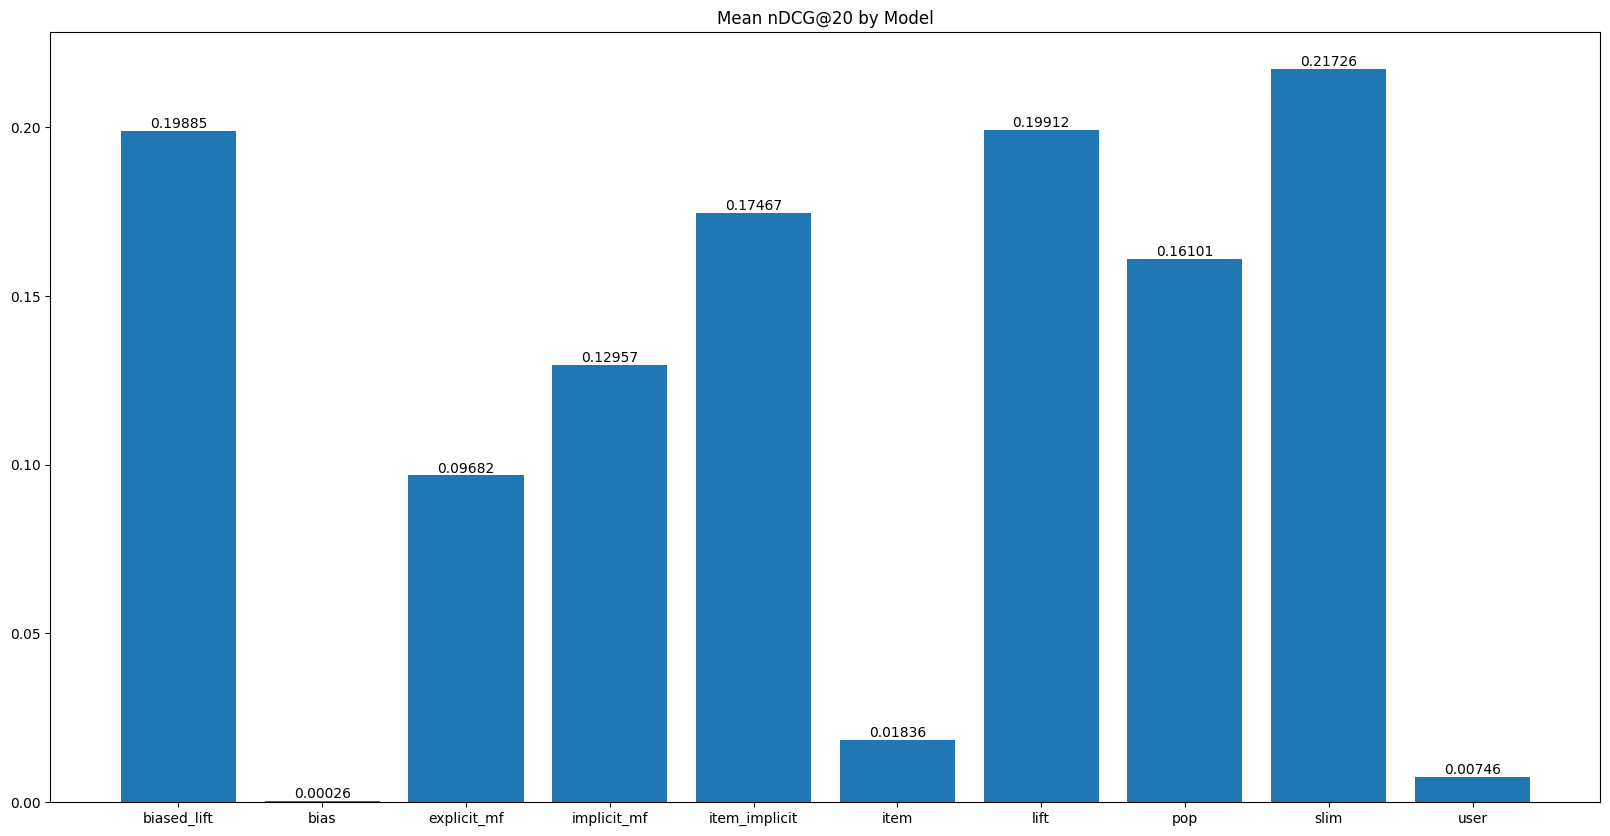

In [21]:
plt.figure(figsize=(20,10))
bars = plt.bar(rows_df["model"], rows_df["ndcg"])
plt.title("Mean nDCG@20 by Model")
plt.bar_label(bars, fmt="%.5f")
plt.show()

#### RBP Graph

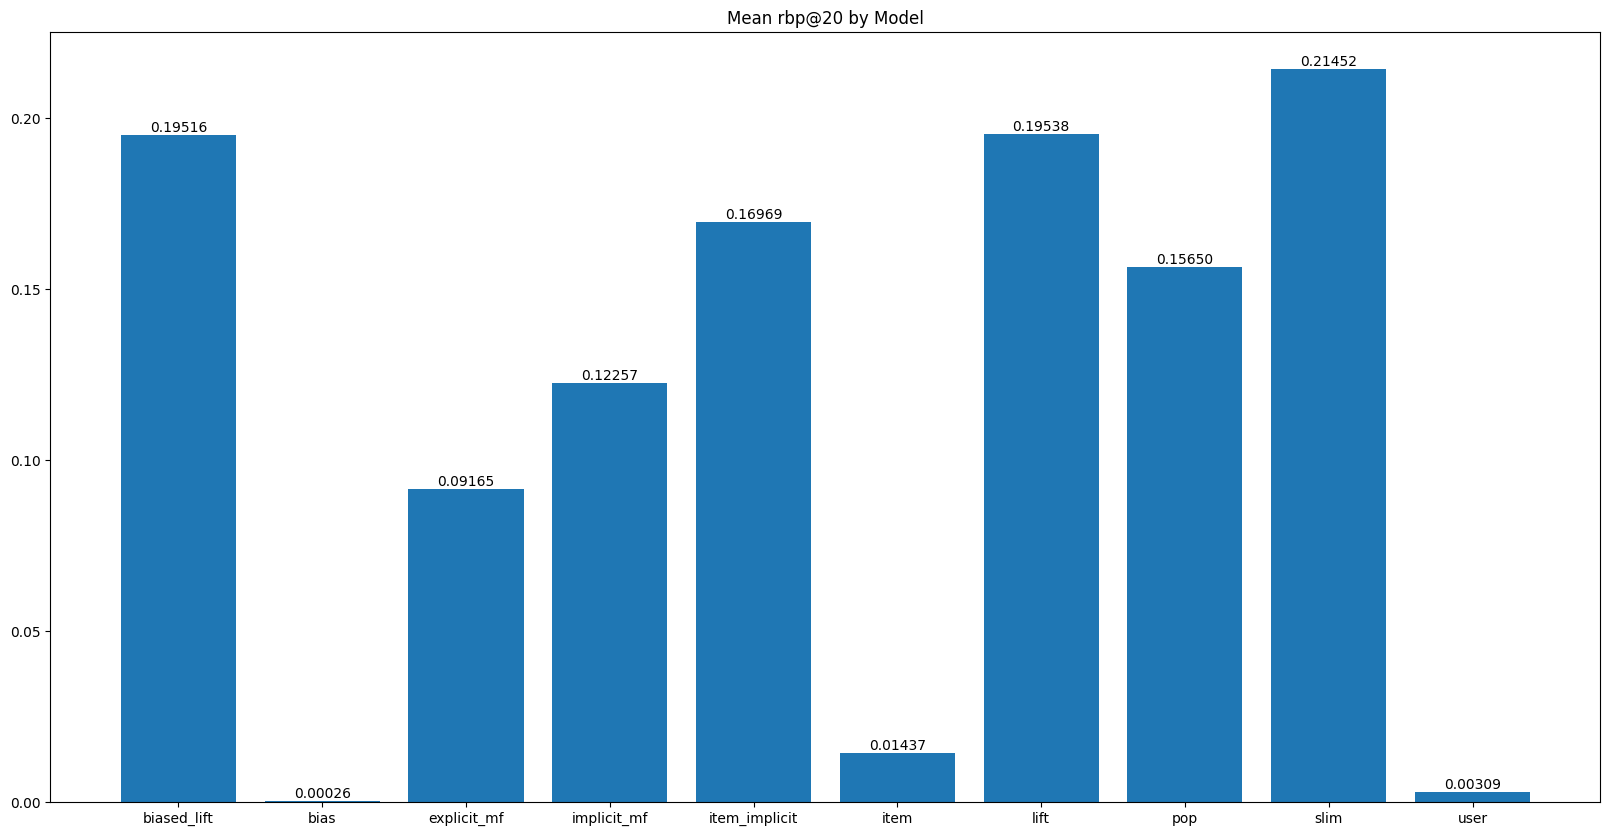

In [22]:
plt.figure(figsize=(20,10))
bars = plt.bar(rows_df["model"], rows_df["rbp"])
plt.title("Mean rbp@20 by Model")
plt.bar_label(bars, fmt="%.5f")
plt.show()

#### RMSE Graph - For Preds

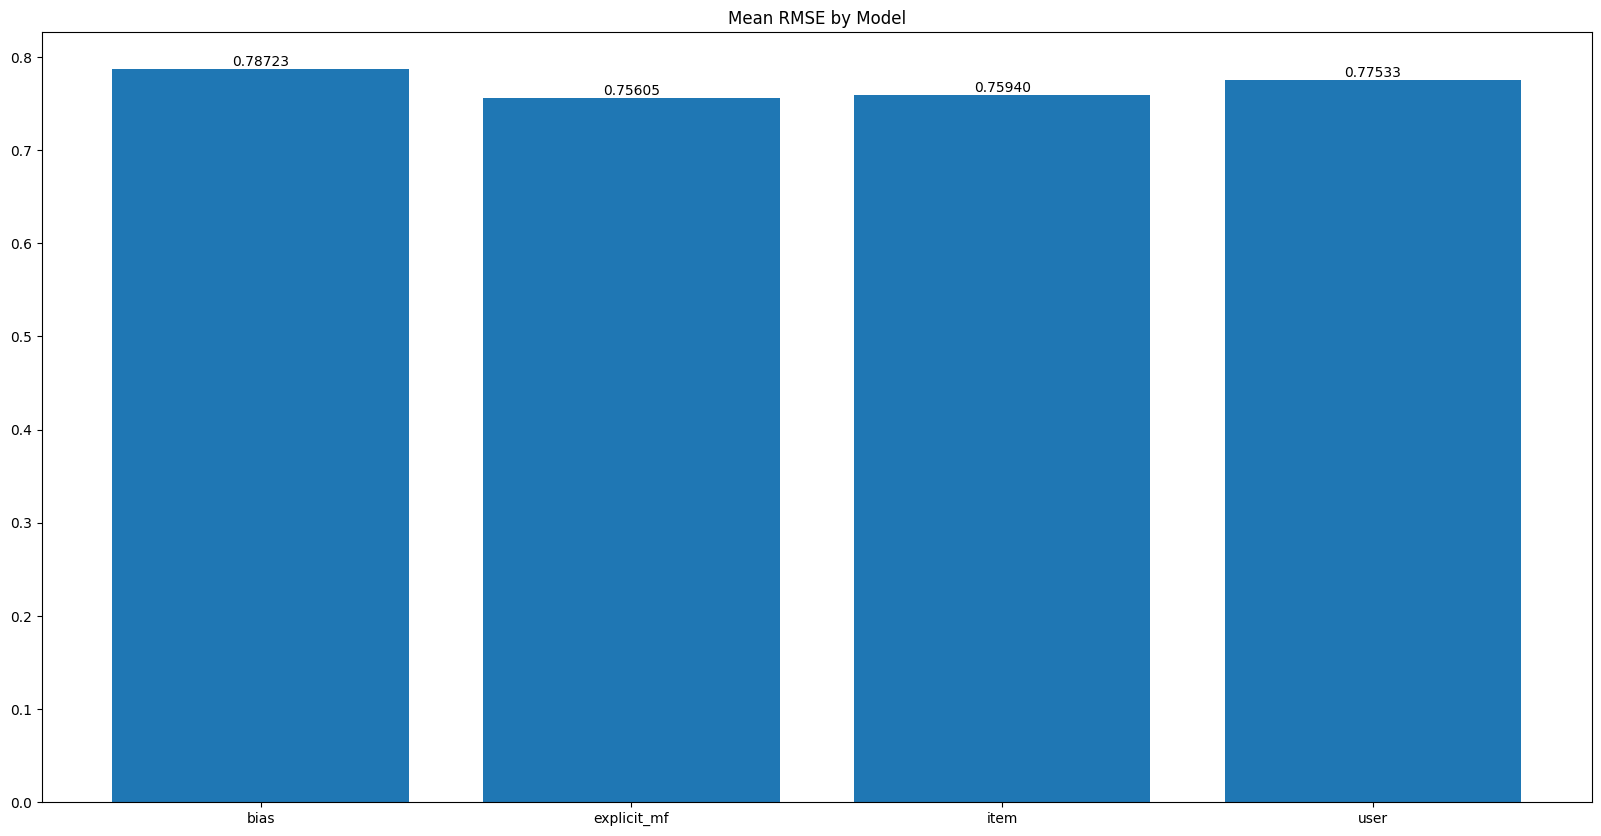

In [23]:
plt.figure(figsize=(20,10))
bars = plt.bar(pred_df["model"], pred_df["rmse"])
plt.title("Mean RMSE by Model")
plt.bar_label(bars, fmt="%.5f")
plt.show()

#### What algorithm(s) seem to perform the best for each task?

The central question of this assignment is: “Which algorithm(s) perform best for each task?” To answer this effectively, it is first necessary to clarify how performance is being measured, as the choice of evaluation metric can significantly influence which algorithm appears to perform best. In this analysis, performance is evaluated using nDCG, RBP, and RMSE. Each metric captures a different aspect of model effectiveness, including ranking quality and prediction accuracy. While a detailed mathematical treatment of these measures is beyond the scope of this discussion, an understanding of their purpose is sufficient for interpreting the results.

nDCG (Normalized Discounted Cumulative Gain) evaluates how well a recommendation system ranks items by measuring not only whether relevant items appear in the recommended list, but also how highly they are ranked. It rewards algorithms that place highly relevant items near the top and applies a logarithmic discount, meaning that lower-ranked items contribute less to the final score. RBP (Rank-Biased Precision) also measures ranking quality but places greater emphasis on user behavior by modelling the probability that a user continues examining results. This means it prioritizes performance at the top of the list even more strongly, reflecting the fact that users are likely to stop browsing after viewing only a few recommendations. RMSE (Root Mean Squared Error) measures how accurately an algorithm predicts user ratings by calculating the average magnitude of the difference between predicted and actual values. Unlike the other two metrics, it treats each prediction independently and does not take ranking or item order into account, focusing purely on numerical prediction accuracy.

A high RMSE combined with low nDCG and low RBP indicates poor overall performance. In such cases, the algorithm fails both to accurately predict user preferences and to rank relevant items effectively, making it unsuitable for both prediction and recommendation tasks.

For recommender systems, strong performance is characterized by high nDCG and high RBP, as these metrics reflect the quality of ranked recommendations, while RMSE should be minimized to ensure accurate predictions. Based on the results, the SLIM algorithm achieves the highest scores for both nDCG and RBP, indicating superior ranking performance. Meanwhile, Explicit_MF produces the lowest RMSE, although only marginally outperforming Item-Item, suggesting comparable prediction accuracy between the two.